In [1]:
import PriceRatioExperiment as PRE

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

In [2]:
N = 100
num = 11

prod_values = np.logspace(-1, 1, num)
labor_coeffs = 1.0/prod_values

In [3]:
T = 500

n = len(labor_coeffs)
n = n*n

l_ratio_df = []
p_ratio_df = []
p_ratio_std_df = []
c1_df = []

for l1 in labor_coeffs:
    
    print(l1)
    
    for l2 in labor_coeffs:
        
        if True: #try:
    
            c1 = 1.0 #np.random.uniform(0, 1.0/l1)
            c2 = 1.0 #1.0/l2*(1.0 - l1*c1)

            pre = PRE.PriceRatioExperiment(N, l1, l2, c1, c2)
            
            #pre.l1 = 1.0
            #pre.l2 = 1.0
            #pre.N1 = 50
            #pre.N2 = 50
            print(pre.l1, pre.l2)
            print(pre.c1, pre.c2)
            print(pre.N1, pre.N2)
            print(pre.l1*pre.c1 + pre.l2*pre.c2)
            print()

            Me_df, Qe_df, ntries_df, p_df = pre.run_experiment(T)

            p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
            p_ratio_std = np.nanstd(p_df[:,0]/p_df[:,1])

            
        #except:
        #    
        #    print('Fail for')
        #    print(l1, l2)
        #    print()
        #    
        #    p_ratio = np.nan
        #    p_ratio_std = np.nan
        
        l_ratio_df.append(l1/l2)
        p_ratio_df.append(p_ratio)
        p_ratio_std_df.append(p_ratio_std)
        c1_df.append(c1)

        
        
        

10.0
10.0 10.0
1.0 1.0
1000 1000
20.0



C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-01-28_Testing_Price_Ratios\PriceRatioExperiment.py:96: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df
C:\Users\Alex\AppData\Local\Temp\ipykernel_10680\1270082856.py:35: RuntimeWarning: Mean of empty slice
  p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
C:\Users\Alex\anaconda3\envs\pytorchgame3.10\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


10.0 6.3095734448019325
1.0 1.0
1000 631
16.309573444801934

10.0 3.9810717055349727
1.0 1.0
1000 398
13.981071705534973

10.0 2.5118864315095797
1.0 1.0
1000 251
12.51188643150958

10.0 1.5848931924611132
1.0 1.0
1000 158
11.584893192461113

10.0 1.0
1.0 1.0
1000 100
11.0

10.0 0.630957344480193
1.0 1.0
1000 63
10.630957344480192

10.0 0.3981071705534971
1.0 1.0
1000 40
10.398107170553498

10.0 0.25118864315095796
1.0 1.0
1000 25
10.251188643150957

10.0 0.15848931924611132
1.0 1.0
1000 16
10.158489319246112

10.0 0.1
1.0 1.0
1000 10
10.1

6.3095734448019325
6.3095734448019325 10.0
1.0 1.0
631 1000
16.309573444801934

6.3095734448019325 6.3095734448019325
1.0 1.0
631 631
12.619146889603865

6.3095734448019325 3.9810717055349727
1.0 1.0
631 398
10.290645150336905

6.3095734448019325 2.5118864315095797
1.0 1.0
631 251
8.821459876311511

6.3095734448019325 1.5848931924611132
1.0 1.0
631 158
7.894466637263045

6.3095734448019325 1.0
1.0 1.0
631 100
7.3095734448019325

6.3095734448019325 0

(0.005, 200.0)

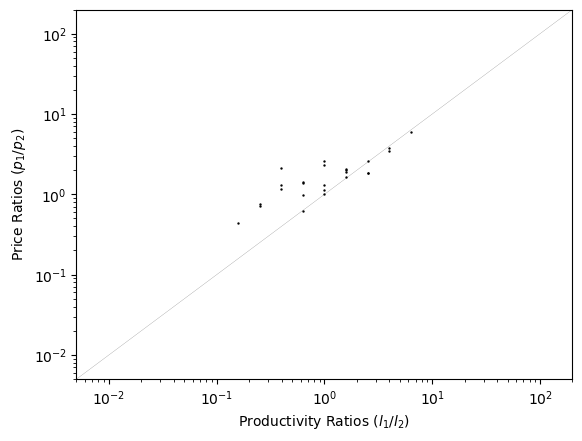

In [7]:
plt.scatter(l_ratio_df, p_ratio_df, s = 0.5, c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Productivity Ratios ($l_1/l_2$)')
plt.ylabel('Price Ratios ($p_1/p_2$)')

x = np.logspace(-3,3,10)
plt.plot(x,x, c='k', lw=0.1)
plt.xlim(5e-3, 2e2)
plt.ylim(5e-3, 2e2)

Text(0, 0.5, 'Price Ratio Standard Deviations')

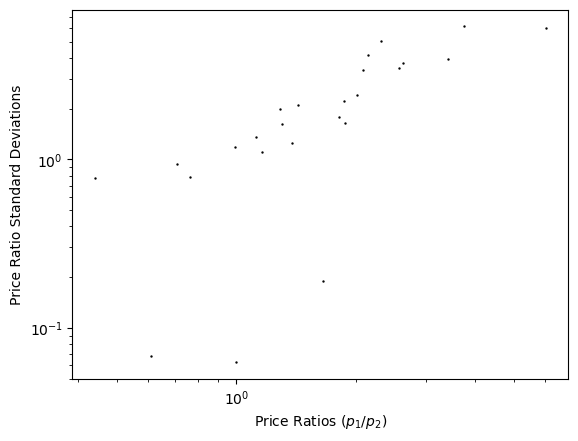

In [5]:
plt.scatter(p_ratio_df, p_ratio_std_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel('Price Ratio Standard Deviations')

Text(0, 0.5, '$\\bar{c}_1$')

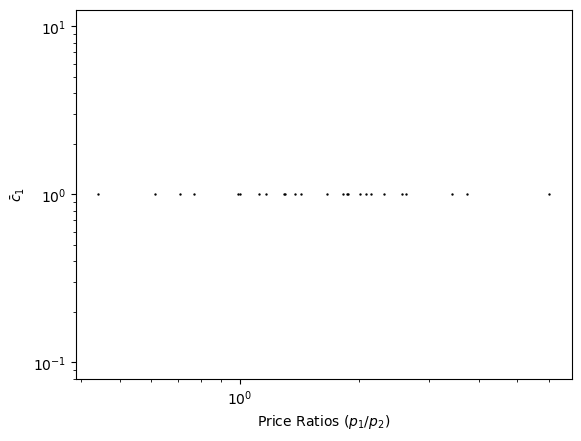

In [6]:
plt.scatter(p_ratio_df, c1_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel(r'$\bar{c}_1$')